In [1]:
import snappy
import networkx as nx
from invariants import *
from knot_graphs import *
from khovanov import *

import pdb
import traceback

# We want to identify pinch moves (planar, non-orientable band moves)

In [28]:
K = snappy.Link("T(6,5)")

In [29]:
K.view()
%gui tk

['arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0']
{((0, 0), (4, 1), 0): 0, ((0, 0), (4, 0), 0): 0, ((0, 1), (4, 2), 0): 0, ((0, 1), (0, 0), 0): 0, ((0, 2), (4, 3), 0): 0, ((0, 2), (0, 1), 0): 0, ((0, 3), (4, 4), 0): 0, ((0, 3), (0, 2), 0): 0, ((0, 4), (4, 4), 0): 0, ((0, 4), (0, 3), 0): 0, ((1, 0), (0, 1), 0): 0, ((1, 0), (0, 0), 0): 0, ((1, 1), (

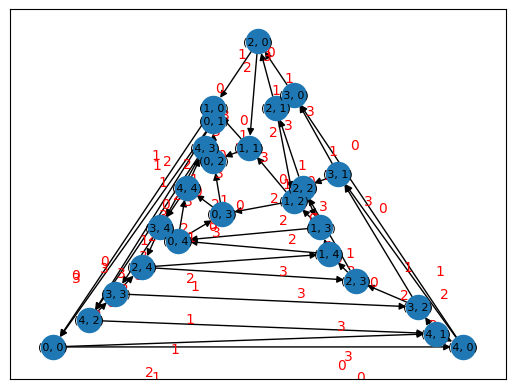

In [30]:
draw_adjacency_graph(K, rad_increment=0.15)

In [ ]:
def planar_band_targets(edge, planar_emb):
    face_nodes = planar_emb.traverse_face(edge[0], edge[1])
    return [(face_nodes[i], face_nodes[(i+1) % len(face_nodes)]) for i in range(len(face_nodes))]

def list_planar_arc_pairs(knot):
    graph = adjacency_graph(knot)
    is_planar, planar_emb = nx.check_planarity(graph)
    if not is_planar:
        return "Knot graph isn't planar!"

    planar_band_arcs = {}
    for e in planar_emb.edges():
        planar_band_arcs[e] = planar_band_targets(e, planar_emb)[1:] # all other edges in the right face associated to e
    return planar_band_arcs

In [33]:
list_planar_arc_pairs(K)

{((0, 0), (0, 1)): [((0, 1), (4, 2)), ((4, 2), (4, 1)), ((4, 1), (0, 0))],
 ((0, 0), (1, 0)): [((1, 0), (0, 1)), ((0, 1), (0, 0))],
 ((0, 0), (4, 0)): [((4, 0), (3, 0)),
  ((3, 0), (2, 0)),
  ((2, 0), (1, 0)),
  ((1, 0), (0, 0))],
 ((0, 0), (4, 1)): [((4, 1), (4, 0)), ((4, 0), (0, 0))],
 ((0, 1), (1, 0)): [((1, 0), (1, 1)), ((1, 1), (0, 2)), ((0, 2), (0, 1))],
 ((0, 1), (0, 2)): [((0, 2), (4, 3)), ((4, 3), (4, 2)), ((4, 2), (0, 1))],
 ((0, 1), (0, 0)): [((0, 0), (1, 0)), ((1, 0), (0, 1))],
 ((0, 1), (4, 2)): [((4, 2), (4, 1)), ((4, 1), (0, 0)), ((0, 0), (0, 1))],
 ((0, 2), (4, 3)): [((4, 3), (4, 2)), ((4, 2), (0, 1)), ((0, 1), (0, 2))],
 ((0, 2), (1, 1)): [((1, 1), (1, 2)), ((1, 2), (0, 3)), ((0, 3), (0, 2))],
 ((0, 2), (0, 1)): [((0, 1), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (0, 2))],
 ((0, 2), (0, 3)): [((0, 3), (4, 4)), ((4, 4), (4, 3)), ((4, 3), (0, 2))],
 ((0, 3), (0, 4)): [((0, 4), (4, 4)), ((4, 4), (0, 3))],
 ((0, 3), (0, 2)): [((0, 2), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (0, 3))]

### TODO - there should be nine total planar arc-pairs
(18 entries in above dict since each band is identified by both of its ends)
<div>
<center>
    <img src="images/pinch_sketch.jpg" width="800"/>
</center>
</div>

What about cases like the arc 2 to arc 5 band?

Its orientable band is twisted, so is the negative twist also orientable?

Are both the negative twist and the 0 twist non-orientable?

### TODO - identify which twists are non-orientable (hence a pinch move) for each planar band (arc pair) above

Write a function that takes a pair of arcs and returns which twist numbers give non-orientable bands.

### Idea: orientable bands yield links, non-orientable bands yield knots.
- Pick any adjacent pair of strands
- Try -1, 0, 1-twist bands on them
    - Take complement + identify resulting manifold using `snappy.Manifold.identify`
    - If complement is a link then the band is orientable.
    - If complement is a knot then the band is non-orientable.

In [34]:
def find_pinch_move(K):
    graph = adjacency_graph(K)
    planar_arc_pairs = list_planar_arc_pairs(K)
    writhe = K.writhe()

    #take first pair of adjacent arcs
    arc0, adj_arcs = list(planar_arc_pairs.items())[0]
    arc1 = adj_arcs[0]
    for twist in [-1,0,1]:
        # get (crossing, strand)'s from edges' (crossing, crossing) in arc1/arc2
        c0 = arc0[0]
        c1 = arc1[0]

        ed0 = graph.get_edge_data(arc0[0], arc0[1])
        if ed0 is None:
            ed0 = graph.get_edge_data(arc0[1], arc0[0])
        if ed0 is None:
            print(f'arc0 {arc0} not found in graph')
            continue
        edge0 = list(ed0.values())[0]
        s0 = edge0['tail_strand']

        ed1 = graph.get_edge_data(arc1[0], arc1[1])
        if ed1 is None:
            ed1 = graph.get_edge_data(arc1[1], arc1[0])
        if ed1 is None:
            print(f'arc1 {arc1} not found in graph')
            continue
        edge1 = list(ed1.values())[0]
        s1 = edge1['tail_strand']

        try:
            # do the band move
            K_prime = K.add_band(([(c0,s0), (c1,s1)], [], twist))

            num_components = len(K_prime.link_components)
            if num_components > 1: # link <---> orientable
                continue
                
            # knot <---> non-orientable
            print('pinch move found')
            print(f'band (({c0},{s0}), ({c1},{s1}), {twist})')

            writhe_prime = K_prime.writhe()
            normal_euler = writhe_prime - writhe
            print(f'e = {normal_euler}')
            
            complement = K_prime.exterior()
            result = complement.identify(extends_to_link=True)
            print(f'attempted identification: {result}')
            
        except Exception as e:
            print(f'band (({c0},{s0}), ({c1},{s1}), {twist}) threw an error: \n {e}')
            print(traceback.format_exc())
        print('-----------------------------')

In [35]:
find_pinch_move(K)

band (((0, 0),1), ((0, 1),2), -1) threw an error: 
 
Traceback (most recent call last):
  File "/tmp/ipykernel_148370/2502092527.py", line 34, in find_pinch_move
    K_prime = K.add_band(([(c0,s0), (c1,s1)], [], twist))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jules/sage/local/var/lib/sage/venv-python3.12/lib/python3.12/site-packages/spherogram/links/links_base.py", line 1644, in add_band
    L = add_one_band(self, band)
        ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jules/sage/local/var/lib/sage/venv-python3.12/lib/python3.12/site-packages/spherogram/links/bands/core.py", line 392, in add_one_band
    assert crossing_labels_are_normalized(link)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError

-----------------------------
band (((0, 0),1), ((0, 1),2), 0) threw an error: 
 
Traceback (most recent call last):
  File "/tmp/ipykernel_148370/2502092527.py", line 34, in find_pinch_move
    K_prime = K.add_band(([(c0,s0), (c1,s1)], [], twist))
  